In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/data.csv")

feature_cols = df.iloc[:, :-1].columns
X = df[feature_cols].values
labels = df["label"].values
y = df["label"].values

print(f"Vector type: {type(X[0])}")
print(f"Vector shape: {X[0].shape}")
print(f"First vector:\n{X[0]}")
print(f"First label:\n{y[0]}")

Vector type: <class 'numpy.ndarray'>
Vector shape: (23,)
First vector:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.2        0.25       0.35643566
 0.7128713  0.06930693 0.42574257 0.7821782  0.         0.
 0.         0.         0.         0.         0.25      ]
First label:
parallel_for


In [3]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Text(0.5, 1.0, 'Class Distribution')

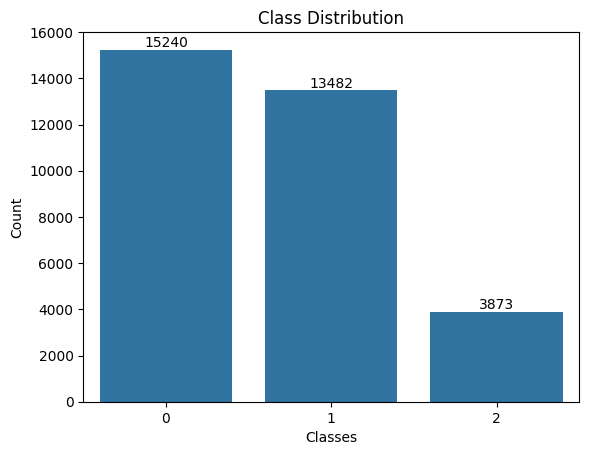

In [4]:
classes, count = np.unique(y, return_counts=True)
ax = sns.barplot(x=classes, y=count)

# Add count labels above each bar
for i, (cls, cnt) in enumerate(zip(classes, count)):
    ax.text(i, cnt, str(cnt), ha="center", va="bottom")

ax.set_xlabel("Classes")
ax.set_ylabel("Count")
ax.set_title("Class Distribution")

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:34:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        none       0.75      0.83      0.79      3048
parallel_for       0.81      0.71      0.76      2696
   reduction       0.71      0.71      0.71       775

    accuracy                           0.77      6519
   macro avg       0.76      0.75      0.75      6519
weighted avg       0.77      0.77      0.77      6519



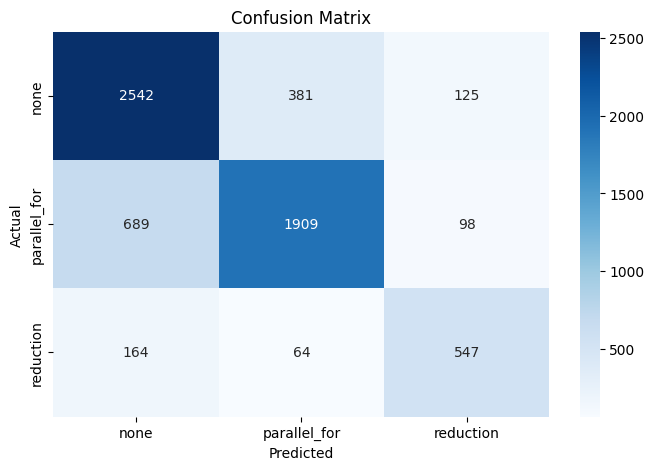

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=9,
    learning_rate=0.03,
    scale_pos_weight=3.0,
    random_state=42,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(
    classification_report(y_test, y_pred, target_names=label_encoder.classes_)
)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)